In [15]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.optimize import minimize

In [6]:
def aux1(x):
    """
    Parameters: x.

    Returns: (e^x - 1)/x.
    """
    # Clip values of x to prevent overflow in np.exp()
    x = np.clip(x, -700, 700)  # Restrict x within the range [-700, 700]: Returns 700 or -700 for values not in the interval
    return (np.exp(x) - 1) / x if x != 0 else 1

def aux2(x, y):
    """
    Patameters: x, y.

    Returns ((e^x-1)/x - (e^y-1)/y) / (x-y).
    """
    if np.isclose(x, y): 
        if np.isclose(x,0):
            return 1/2
        x_clipped = np.clip(x, -700, 700) # Cap x to prevent overflow
        return (x_clipped*np.exp(x_clipped) - np.exp(x_clipped) +1) / (x_clipped**2) 
    return (aux1(x) - aux1(y)) / (x - y)
    

def safe_divide(a, b, epsilon=1e-10):
    return a / (b + epsilon)


def double_integration(f, a, b, c, d):
    """
    Integrate a two-variable function f over the region [a, b] x [c, d]
    using a higher limit on subdivisions.

    Parameters:
    - f: Function to integrate, must accept two variables (x, y).
    - a, b: Integration limits for the first variable (x).
    - c, d: Integration limits for the second variable (y), can be numbers or functions of x.

    Returns:
    - result: The computed integral value.
    - error: An estimate of the absolute error in the result.
    """
    # If c and d are functions of x, pass them directly; otherwise, use lambda to make them constant
    lower_y = c if callable(c) else lambda x: c
    upper_y = d if callable(d) else lambda x: d

    # Perform the double integration
    result, error = integrate.dblquad(f, a, b, lower_y, upper_y, epsabs=1.49e-8, epsrel=1.49e-8)
    return result, error

# Gradient descent
def numerical_gradient(f, x, y, h=1e-5):
    """Compute the numerical gradient of a 2D function using central difference."""
    grad_x = (f(x + h, y) - f(x - h, y)) / (2 * h)
    grad_y = (f(x, y + h) - f(x, y - h)) / (2 * h)
    return np.array([grad_x, grad_y])


def gradient_descent(f, initial_point, learning_rate=1e-4, max_iterations=100, tolerance=1e-3, threshold=1e-6):
    """Find the minimum of function f using gradient descent."""
    x0, y0 = initial_point
    grad = numerical_gradient(f, x0, y0)
    number_of_iterations = 0

    # Initialize tqdm loading bar
    with tqdm(total=max_iterations) as pbar:
        while np.sqrt(grad[0]**2 + grad[1]**2) > tolerance and number_of_iterations < max_iterations:
            number_of_iterations += 1

            # Update the progress bar
            pbar.update(1)

            # Perform gradient descent step
            x0 -= learning_rate * grad[0]
            y0 -= learning_rate * grad[1]

            grad = numerical_gradient(f, x0, y0)

    # Round small values to zero if they are below the threshold
    x0 = round(x0) if abs(x0-round(x0)) < threshold else x0
    y0 = round(y0) if abs(y0-round(y0)) < threshold else y0

    # print("Number of iterations:", number_of_iterations)
    # print("Minimum attained at: ", (x0, y0))
    # print("Gradient at that point: ", grad)
    # print("Minimum value: ", f(x0, y0))

    return x0, y0, f(x0, y0)

In [36]:
class Polytope:
    """A class representing a polytope defined by its vertices."""

    def __init__(self, vertices):
        """
        Initialize the polytope with a list of vertices.

        Args:
            vertices (list of tuples): List of (x, y) tuples representing vertices.
        """
        self.vertices = vertices

    def volume(self):
        """
        Compute the area (volume in 2D) of the polytope using the Shoelace formula.

        Returns:
            float: The computed area of the polytope.
        """
        vertices = self.vertices[:]
        vertices.append(vertices[0])  # Repeat the first point to close the loop
        xs, ys = zip(*vertices)
        volume = 0.5 * sum(xs[i] * ys[i + 1] - xs[i + 1] * ys[i] for i in range(len(self.vertices)))
        return abs(volume)

    def plot(self):
        """Plot the polytope using matplotlib."""
        vertices = self.vertices[:]
        vertices.append(vertices[0])
        xs, ys = zip(*vertices)
        plt.figure()
        plt.plot(xs, ys)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Polytope Plot')
        plt.show()

    def update_vertices(self, new_vertices):
        self.vertices = new_vertices

    def polar(self):
        """
        Compute the polar polytope.

        Returns:
            Polytope: The polar polytope as a new Polytope object.
        """
        vertices = self.vertices[:]
        vertices.append(vertices[0])
        polar_polytope = []
        xs, ys = zip(*vertices)
        for i in range(len(self.vertices)):
            L = xs[i] * ys[i + 1] - xs[i + 1] * ys[i]
            if L == 0:
                continue  # Avoid division by zero
            polar_x = (ys[i + 1] - ys[i]) / L
            polar_y = (xs[i] - xs[i + 1]) / L
            polar_polytope.append((polar_x, polar_y))
        return Polytope(polar_polytope)
    
    def polar_plot(self): 
        # Create a figure and two subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

        # Body plot
        vertices = self.vertices[:]
        vertices.append(vertices[0])
        xs, ys = zip(*vertices) #create lists of x and y values
        ax1.plot(xs,ys) 
        ax1.axhline(0, color='black', linewidth=0.5)  # Add x-axis
        ax1.axvline(0, color='black', linewidth=0.5)  # Add y-axis
        ax1.set_xlim(-2, 2)  # Adjust x-axis limits to zoom out
        ax1.set_ylim(-2, 2)  # Adjust y-axis limits to zoom out
        ax1.set_title('Convex body')

        # Polar plot
        vertices = self.polar().vertices[:]
        vertices.append(vertices[0])
        xs, ys = zip(*vertices)  # create lists of x and y values
        ax2.plot(xs, ys)
        ax2.axhline(0, color='black', linewidth=0.5)  # Add x-axis
        ax2.axvline(0, color='black', linewidth=0.5)  # Add y-axis
        ax1.set_xlim(-2, 2)  # Adjust x-axis limits to zoom out
        ax1.set_ylim(-2, 2)  # Adjust y-axis limits to zoom out
        ax2.set_title('Polar body')

        # Adjust layout to prevent overlap
        plt.tight_layout()

        # Show the plots    
        plt.show()
    
    def Mahler(self):    
        """
        Compute the Mahler volume of the polytope. 

        """
        return 2 * self.volume() * self.polar().volume()
    
    def barycenter(self):
        """
        Compute the barycenter (centroid) of a convex polygon in 2D.

        Args:
            vertices (list of tuples): List of (x, y) tuples representing the vertices of the polygon in counterclockwise order.

        Returns:
            tuple: The (x, y) coordinates of the barycenter.
        """
        # Close the polygon by appending the first vertex at the end
        vertices = self.vertices[:]
        vertices.append(vertices[0])

        # Number of vertices
        n = len(vertices) - 1

        # Initialize area and barycenter coordinates
        A = self.volume()
        C_x = 0
        C_y = 0

        # Compute barycenter coordinates using the formulas
        for i in range(n):
            x_i, y_i = vertices[i]
            x_ip1, y_ip1 = vertices[i + 1]
            # Compute the cross product and area
            cross_product = x_i * y_ip1 - x_ip1 * y_i
            # Compute the centroid coordinates
            C_x += (x_i + x_ip1) * cross_product
            C_y += (y_i + y_ip1) * cross_product

        # Finalize the area and barycenter coordinates
        C_x /= (6 * A)
        C_y /= (6 * A)

        return (C_x, C_y)

    def translate(self, x, y):
        """
        Translate the polytope by a given vector (x, y).

        Args:
            x (float): The amount to translate in the x-direction.
            y (float): The amount to translate in the y-direction.

        Returns:
            list of tuples: A new list of vertices representing the translated polytope.
        """
        vertices = self.vertices[:] # make a copy of the vertices
        translatedP = []  
        for i in range(len(vertices)):
            translatedP.append((vertices[i][0]- x, vertices[i][1] - y))
        return Polytope(translatedP)


    def SantaloPoint(self, p="inf"): 
        # Step 1: Define the function M(p, P - (x, y))
        def F(x,y):
            return self.translate(x, y).M(p)

        # Step 2: Select the initial point
        n = len(self.vertices)
        x_avg = sum(x for x, y in self.vertices) / n
        y_avg = sum(y for x, y in self.vertices) / n

        initial_point = (x_avg, y_avg)

        # Step 2: Run Gradient Descent
        result_x, result_y, min_value = gradient_descent(F, initial_point)

        return result_x, result_y

    def safe_exph1(self, x, y):
        vertices = self.vertices[:]  # Make a copy of the vertices
        vertices.append(vertices[0])
        z = np.array([x, y])
        exph1 = 0
        for i in range(len(self.vertices)):
            M = np.array([vertices[i], vertices[i+1]]).T
            xi = M.T.dot(z)[0]
            eta = M.T.dot(z)[1]
            
            # Prevent overflow and handle invalid values
            det_M = np.clip(np.linalg.det(M), -1e150, 1e150)  # Clip values to prevent overflow
            g_val = np.clip(aux2(xi, eta), -1e150, 1e150)  # Also clip auxiliary function results
            
            exph1 += det_M * g_val

        return exph1 / (self.volume() + 1e-10)  # Add epsilon to avoid division by zero

    def M1(self):
        """
        Compute the L1-Mahler volume of the polytope.

        Returns:
            float: The computed M1 volume.
        """
        prec = 30  # precision of integration

        def G(x, y):
            return safe_divide(1, self.safe_exph1(x,y))

        L1polar = double_integration(G, -prec, prec, lambda _: -prec, lambda _: prec)
        return L1polar[0] * self.volume()

    def exph(self, p, x, y):
        """Compute the exponential Lp-support function of the polytope."""
        return (self.safe_exph1(p * x, p * y)) ** (1 / p)

    def h(self, p, x, y):
        """Compute the Lp-support function of the polytope."""
        return np.log(self.exph(p, x, y))

    def M(self, p="inf"):
        """
        Compute the Mp volume for the polytope.

        Args:
            p (float): The exponent parameter p, or 
            p = "inf": for the classical Mahler volume.

        Returns:
            float: The computed Lp-Mahler volume.
        """

        if p == "inf": 
            return self.Mahler()
        
        else: 
            prec = 20  # precision of integration

            def G(x, y):
                return safe_divide(1, self.exph(p, x, y))

            Lppolar = double_integration(G, -prec, prec, lambda _: -prec, lambda _: prec)
            return Lppolar[0] * self.volume()

    def Cov(self): 
        """
        Compute the covariance matrix of a convex polygon in 2D.

        Returns:
            np.ndarray: The 2-by-2 covariance matrix of the polygon.
        """
        # Make a copy of vertices and close the polygon by appending the first vertex at the end
        vertices = self.vertices[:]
        vertices.append(vertices[0])

        # Number of vertices
        n = len(vertices) - 1

        # Initialize second moments
        A = self.volume()
        I_xx = 0
        I_xy = 0
        I_yy = 0

        # Compute the second moments using shoelace formulas
        for i in range(n):
            x_i, y_i = vertices[i]
            x_ip1, y_ip1 = vertices[i + 1]
            
            # Compute the cross product
            cross_product = x_i * y_ip1 - x_ip1 * y_i
            
            # Compute the second moments
            I_xx += (x_i**2 + x_i * x_ip1 + x_ip1**2) * cross_product
            I_xy += (x_i * y_ip1 + 2 * x_i * y_i + 2 * x_ip1 * y_ip1 + x_ip1 * y_i) * cross_product
            I_yy += (y_i**2 + y_i * y_ip1 + y_ip1**2) * cross_product

        # Normalize the second moments by the area
        I_xx /= (12 * A)
        I_xy /= (24 * A)
        I_yy /= (12 * A)

        # Compute barycenter once to avoid redundant calls
        b_x, b_y = self.barycenter()

        # Define the covariance matrix components
        C_xx = I_xx - b_x**2 
        C_xy = I_xy - b_x * b_y
        C_yy = I_yy - b_y**2

        return np.array([[C_xx, C_xy], [C_xy, C_yy]])

    def isotropic(self):
        """
        Compute the isotropic constant of the convex polygon.
        
        Returns:
            float: The isotropic constant of the polygon.
        """
        # Calculate the covariance matrix
        cov_matrix = self.Cov()

        # Compute the determinant of the covariance matrix
        det_cov = np.linalg.det(cov_matrix)

        # Compute the volume (area) of the convex polygon
        volume = self.volume()

        # Calculate the isotropic constant using the formula
        L_K = (det_cov ** (1/4)) / (volume ** 0.5)

        return L_K


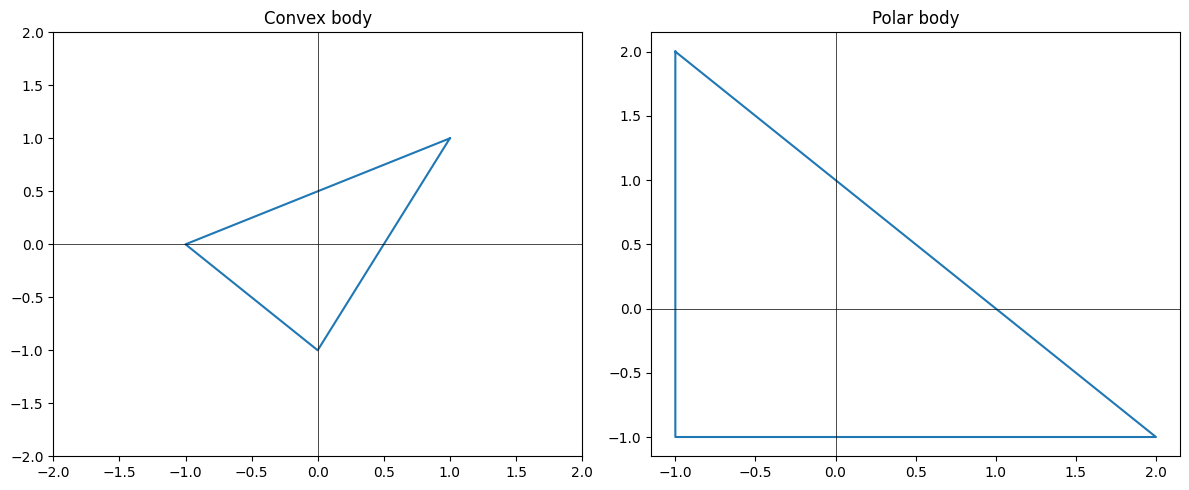

In [10]:
triangle = Polytope([(1,1), (-1,0), (0,-1)])
triangle.polar_plot()

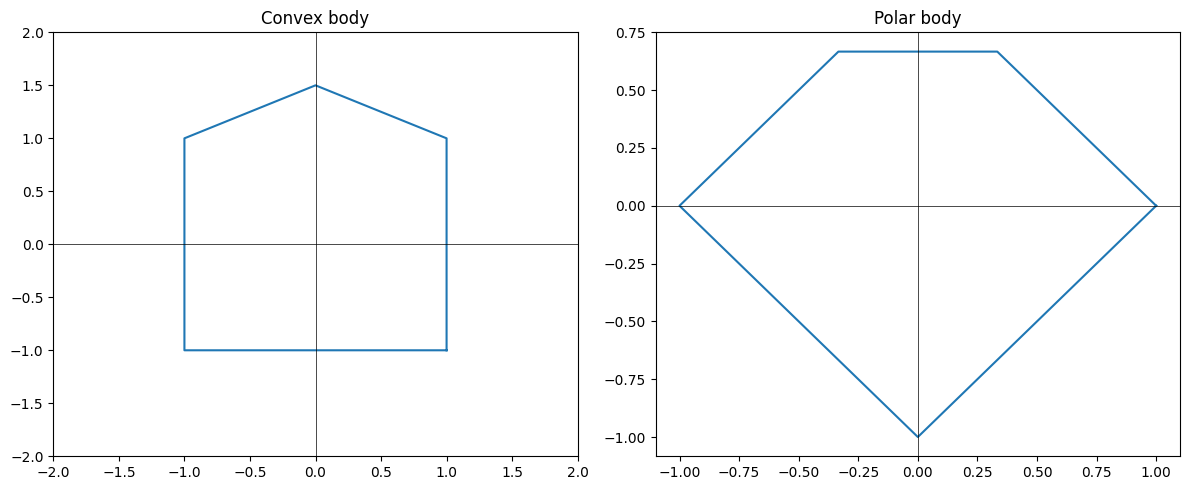

In [11]:
pentagon = Polytope([(1, -1), (1, 1), (0, 3/2), (-1, 1), (-1, -1)])
pentagon.polar_plot()

In [22]:
# function to minimize
def F(y): 
    return pentagon.translate(0,y).M()

F(0)

17.0

In [23]:
minimize(F, 0, method="CG")

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 16.902841565509306
       x: [ 8.402e-02]
     nit: 1
     jac: [-2.384e-07]
    nfev: 18
    njev: 8

In [24]:
minimize(F, 0, method="BFGS")

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 16.902841565509302
        x: [ 8.402e-02]
      nit: 3
      jac: [ 2.384e-07]
 hess_inv: [[ 3.679e-02]]
     nfev: 12
     njev: 6

In [25]:
minimize(F, 0, method='L-BFGS-B')

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 16.902841565509306
        x: [ 8.402e-02]
      nit: 3
      jac: [-3.553e-07]
     nfev: 12
     njev: 6
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>

In [26]:
minimize(F, 0, method='Nelder-Mead')

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 16.902841572224972
             x: [ 8.400e-02]
           nit: 18
          nfev: 36
 final_simplex: (array([[ 8.400e-02],
                       [ 8.406e-02]]), array([ 1.690e+01,  1.690e+01]))

In [37]:
# function to minimize
def G(y): 
    return pentagon.translate(0,y).M(1)

G(0)

102.66004385743238

In [40]:
import cProfile
cProfile.run('pentagon.M(1)')


         29192518 function calls (29191258 primitive calls) in 10.914 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
   603678    0.625    0.000    1.943    0.000 2682757281.py:1(aux1)
   302925    0.333    0.000    7.282    0.000 2682757281.py:11(aux2)
    60585    0.009    0.000    0.009    0.000 2682757281.py:25(safe_divide)
        1    0.000    0.000   10.914   10.914 2682757281.py:29(double_integration)
    60586    0.065    0.000    0.160    0.000 3496448798.py:13(volume)
    60585    0.768    0.000   10.836    0.000 3496448798.py:173(safe_exph1)
    60585    0.026    0.000   10.862    0.000 3496448798.py:206(exph)
        1    0.000    0.000   10.914   10.914 3496448798.py:214(M)
   363516    0.051    0.000    0.051    0.000 3496448798.py:23(<genexpr>)
    60585    0.021    0.000   10.892    0.000 3496448798.py:232(G)
      315    0.000    0.000    0.000    0.000 3496448798.py:235(<lambda>)
        1    0.000    0.